Down Syndrome Detection using ResNet50
Mounted at /content/drive
Google Drive Mounted Successfully!
ZIP Found Successfully
Extracting dataset...
Dataset Extracted Successfully!
Dataset Path: /content/dataset/dataset
Train: /content/dataset/dataset/train
Validation: /content/dataset/dataset/val
Test: /content/dataset/dataset/test
Found 27244 images belonging to 2 classes.
Found 5838 images belonging to 2 classes.
Found 5840 images belonging to 2 classes.

Detected Classes
{'down_syndrome': 0, 'healthy': 1}
{0: 'down_syndrome', 1: 'healthy'}

Class Weights
{0: np.float64(1.0013231402528668), 1: np.float64(0.9986803519061583)}

Training Images : 27244
Validation Images : 5838
Testing Images : 5840


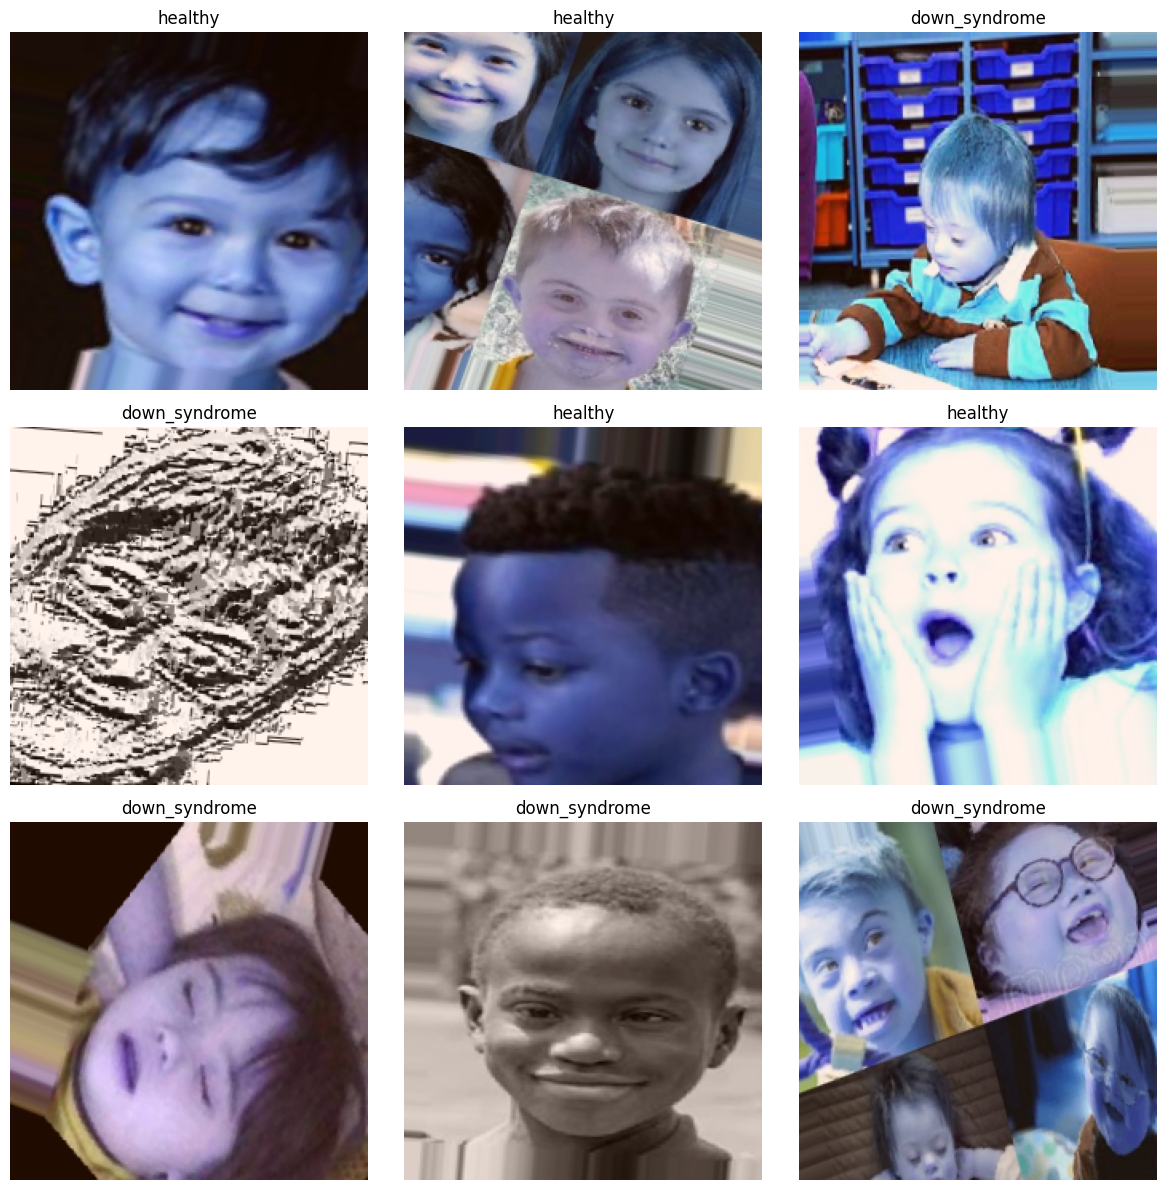


PART 1 COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# DATASET LOADING FROM GOOGLE DRIVE
# ============================================================

# -------------------------------
# STEP 1 : IMPORT LIBRARIES
# -------------------------------

import os
import zipfile
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from google.colab import drive

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.utils.class_weight import compute_class_weight

print("="*60)
print("Down Syndrome Detection using ResNet50")
print("="*60)

# -------------------------------
# STEP 2 : MOUNT GOOGLE DRIVE
# -------------------------------

drive.mount('/content/drive')

print("Google Drive Mounted Successfully!")

# -------------------------------
# STEP 3 : ZIP FILE PATH
# -------------------------------

zip_file = "/content/drive/MyDrive/dataset.zip"

if not os.path.exists(zip_file):
    raise FileNotFoundError("dataset.zip not found in My Drive")

print("ZIP Found Successfully")

# -------------------------------
# STEP 4 : EXTRACT DATASET
# -------------------------------

extract_path = "/content"

print("Extracting dataset...")

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully!")

# -------------------------------
# STEP 5 : DATASET PATH
# -------------------------------

dataset_path = "/content/dataset/dataset"

if not os.path.exists(dataset_path):
    raise Exception("Dataset folder not found!")

print("Dataset Path:", dataset_path)

train_path = os.path.join(dataset_path, "train")
val_path = os.path.join(dataset_path, "val")
test_path = os.path.join(dataset_path, "test")

print("Train:", train_path)
print("Validation:", val_path)
print("Test:", test_path)

# -------------------------------
# STEP 6 : PARAMETERS
# -------------------------------

IMAGE_SIZE = (224,224)
BATCH_SIZE = 16
SEED = 42

# -------------------------------
# STEP 7 : DATA AUGMENTATION
# -------------------------------

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    brightness_range=[0.8,1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# -------------------------------
# STEP 8 : LOAD DATA
# -------------------------------

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=SEED
)

validation_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# -------------------------------
# STEP 9 : CLASS MAPPING
# -------------------------------

print("\nDetected Classes")

print(train_generator.class_indices)

class_mapping = train_generator.class_indices

index_to_class = {v:k for k,v in class_mapping.items()}

print(index_to_class)

with open("class_mapping.json","w") as f:
    json.dump(class_mapping,f)

# -------------------------------
# STEP 10 : CLASS WEIGHTS
# -------------------------------

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(weights))

print("\nClass Weights")

print(class_weights)

# -------------------------------
# STEP 11 : DATASET INFO
# -------------------------------

print("\nTraining Images :", train_generator.samples)
print("Validation Images :", validation_generator.samples)
print("Testing Images :", test_generator.samples)

# -------------------------------
# STEP 12 : DISPLAY SAMPLE IMAGES
# -------------------------------

images, labels = next(train_generator)

plt.figure(figsize=(12,12))

for i in range(9):

    plt.subplot(3,3,i+1)

    img = images[i]

    img = (img-img.min())/(img.max()-img.min()+1e-8)

    plt.imshow(img)

    plt.title(index_to_class[int(labels[i])])

    plt.axis("off")

plt.tight_layout()

plt.show()

print("\nPART 1 COMPLETED SUCCESSFULLY")

In [ ]:
# ============================================================
# RESNET50 TRANSFER LEARNING
# ============================================================

import tensorflow as tf

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.regularizers import l2

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint

print("="*60)
print("Building ResNet50 Model")
print("="*60)

# --------------------------------------------------
# LOAD PRETRAINED RESNET50
# --------------------------------------------------

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base model
base_model.trainable = False

print("ResNet50 Loaded Successfully")

# --------------------------------------------------
# CUSTOM CLASSIFIER
# --------------------------------------------------

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dropout(0.50)(x)

x = Dense(
    512,
    activation="relu",
    kernel_regularizer=l2(0.001)
)(x)

x = BatchNormalization()(x)

x = Dropout(0.40)(x)

x = Dense(
    256,
    activation="relu",
    kernel_regularizer=l2(0.001)
)(x)

x = BatchNormalization()(x)

x = Dropout(0.30)(x)

output = Dense(
    1,
    activation="sigmoid"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

# --------------------------------------------------
# COMPILE MODEL
# --------------------------------------------------

model.compile(

    optimizer=Adam(
        learning_rate=1e-4
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

print("\nMODEL SUMMARY\n")

model.summary()

# --------------------------------------------------
# CALLBACKS
# --------------------------------------------------

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True,

    verbose=1

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=2,

    min_lr=1e-7,

    verbose=1

)

checkpoint = ModelCheckpoint(

    "best_resnet50_model.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1

)

callbacks = [

    early_stop,

    reduce_lr,

    checkpoint

]

# --------------------------------------------------
# INITIAL TRAINING
# --------------------------------------------------

INITIAL_EPOCHS = 10

print("\n")
print("="*60)
print("INITIAL TRAINING")
print("="*60)

history1 = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=INITIAL_EPOCHS,

    callbacks=callbacks,

    class_weight=class_weights

)

# --------------------------------------------------
# FINE TUNING
# --------------------------------------------------

print("\n")
print("="*60)
print("FINE TUNING")
print("="*60)

base_model.trainable = True

# Freeze lower layers
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(

    optimizer=Adam(
        learning_rate=1e-5
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

FINE_TUNE_EPOCHS = 10

history2 = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=FINE_TUNE_EPOCHS,

    callbacks=callbacks,

    class_weight=class_weights

)

# --------------------------------------------------
# LOAD BEST MODEL
# --------------------------------------------------

print("\nLoading Best Model...\n")

model = tf.keras.models.load_model(
    "best_resnet50_model.keras"
)

print("Best Model Loaded Successfully!")

# --------------------------------------------------
# SAVE FINAL MODEL
# --------------------------------------------------

model.save("DownSyndrome_ResNet50.keras")

print("\nFinal Model Saved Successfully!")

print("\nPART 2 COMPLETED SUCCESSFULLY")

Building ResNet50 Model
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet50 Loaded Successfully

MODEL SUMMARY



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,779,649 (94.53 MB)

 Trainable params: 1,186,305 (4.53 MB)

 Non-trainable params: 23,593,344 (90.00 MB)



INITIAL TRAINING
Epoch 1/10
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.6214 - auc: 0.6666 - loss: 1.8970 - precision: 0.6231 - recall: 0.6249
Epoch 1: val_accuracy improved from None to 0.75248, saving model to best_resnet50_model.keras

Epoch 1: finished saving model to best_resnet50_model.keras
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 505s 286ms/step - accuracy: 0.6625 - auc: 0.7219 - loss: 1.8069 - precision: 0.6633 - recall: 0.6619 - val_accuracy: 0.7525 - val_auc: 0.8671 - val_loss: 1.5942 - val_precision: 0.8770 - val_recall: 0.5881 - learning_rate: 1.0000e-04
Epoch 2/10
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.7075 - auc: 0.7817 - loss: 1.6649 - precision: 0.7067 - recall: 0.7002
Epoch 2: val_accuracy improved from 0.75248 to 0.75848, saving model to best_resnet50_model.keras

Epoch 2: finished saving model to best_resnet50_model.keras
1703/1703 ━━━━━━━━━━━━━━━━━━━━ 481s 282ms/step - accuracy: 0.7101 - auc: 0.7843 - loss: 1.6395 - precision: 0.7144 - re

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 5840 images belonging to 2 classes.
Detected Classes:
{'down_syndrome': 0, 'healthy': 1}

Best model loaded successfully.

365/365 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - accuracy: 0.9385 - auc: 0.9881 - loss: 0.4403 - precision: 0.9439 - recall: 0.9326

TEST RESULTS
Loss      : 0.4403
Accuracy  : 93.85%
Precision : 0.9439
Recall    : 0.9326
AUC       : 0.9881
365/365 ━━━━━━━━━━━━━━━━━━━━ 25s 55ms/step

SCIKIT-LEARN METRICS
Accuracy : 93.85%
Precision: 0.9439
Recall   : 0.9326
F1 Score : 0.9382
ROC AUC  : 0.9881

Classification Report

               precision    recall  f1-score   support

down_syndrome       0.93      0.94      0.94      2916
      healthy       0.94      0.93      0.94      2924

     accuracy                           0.94      5840
    macro avg       0.94      0.94      0.94      5840
 weighted avg       0.94      0.94      0.94     

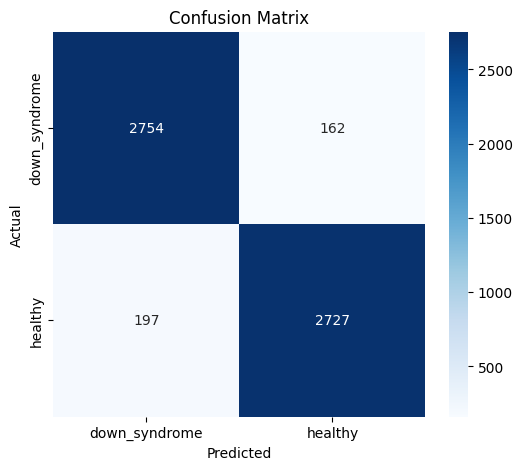

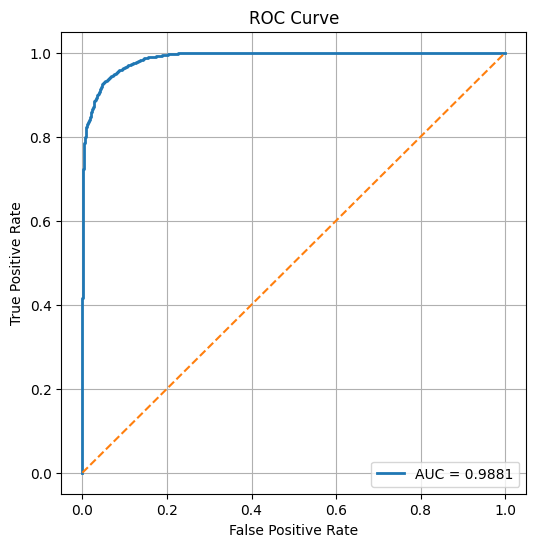


PART 3 COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# MODEL EVALUATION
# ============================================================

import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from google.colab import drive

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# --------------------------------------------------
# MOUNT GOOGLE DRIVE
# --------------------------------------------------

drive.mount('/content/drive')

# --------------------------------------------------
# DATASET PATH
# --------------------------------------------------

dataset_path = "/content/dataset/dataset"

# If dataset isn't already extracted in this runtime,
# uncomment the extraction block below and set zip path.
#
# import zipfile
# zip_path = "/content/drive/MyDrive/dataset.zip"
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall("/content")

test_path = os.path.join(dataset_path, "test")

IMAGE_SIZE = (224,224)
BATCH_SIZE = 16

# --------------------------------------------------
# LOAD TEST DATA
# --------------------------------------------------

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

class_indices = test_generator.class_indices
index_to_class = {v:k for k,v in class_indices.items()}

print("Detected Classes:")
print(class_indices)

# --------------------------------------------------
# LOAD BEST MODEL
# --------------------------------------------------

model = tf.keras.models.load_model("best_resnet50_model.keras")

print("\nBest model loaded successfully.\n")

# --------------------------------------------------
# EVALUATE
# --------------------------------------------------

loss, accuracy, precision_metric, recall_metric, auc_metric = model.evaluate(
    test_generator,
    verbose=1
)

print("\n==============================")
print("TEST RESULTS")
print("==============================")

print(f"Loss      : {loss:.4f}")
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision_metric:.4f}")
print(f"Recall    : {recall_metric:.4f}")
print(f"AUC       : {auc_metric:.4f}")

# --------------------------------------------------
# PREDICTIONS
# --------------------------------------------------

test_generator.reset()

pred_probs = model.predict(test_generator, verbose=1)

pred_labels = (pred_probs >= 0.5).astype(int).flatten()

true_labels = test_generator.classes

# --------------------------------------------------
# METRICS
# --------------------------------------------------

accuracy = accuracy_score(true_labels, pred_labels)
precision = precision_score(true_labels, pred_labels)
recall = recall_score(true_labels, pred_labels)
f1 = f1_score(true_labels, pred_labels)
roc_auc = roc_auc_score(true_labels, pred_probs)

print("\n==============================")
print("SCIKIT-LEARN METRICS")
print("==============================")

print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

# --------------------------------------------------
# CLASSIFICATION REPORT
# --------------------------------------------------

print("\nClassification Report\n")

print(
    classification_report(
        true_labels,
        pred_labels,
        target_names=list(class_indices.keys())
    )
)

# --------------------------------------------------
# CONFUSION MATRIX
# --------------------------------------------------

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=list(class_indices.keys()),
    yticklabels=list(class_indices.keys())
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# --------------------------------------------------
# ROC CURVE
# --------------------------------------------------

fpr, tpr, thresholds = roc_curve(true_labels, pred_probs)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

print("\nPART 3 COMPLETED SUCCESSFULLY")

Grad-CAM Visualization
Model Loaded Successfully!

Upload an image


Saving down_1_brightness.jpg to down_1_brightness.jpg
Image: down_1_brightness.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step

Prediction
Predicted Class : down_syndrome
Confidence : 99.48 %
Healthy Probability : 0.52 %
Down Syndrome Probability : 99.48 %

Last Convolution Layer : conv5_block3_3_conv


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


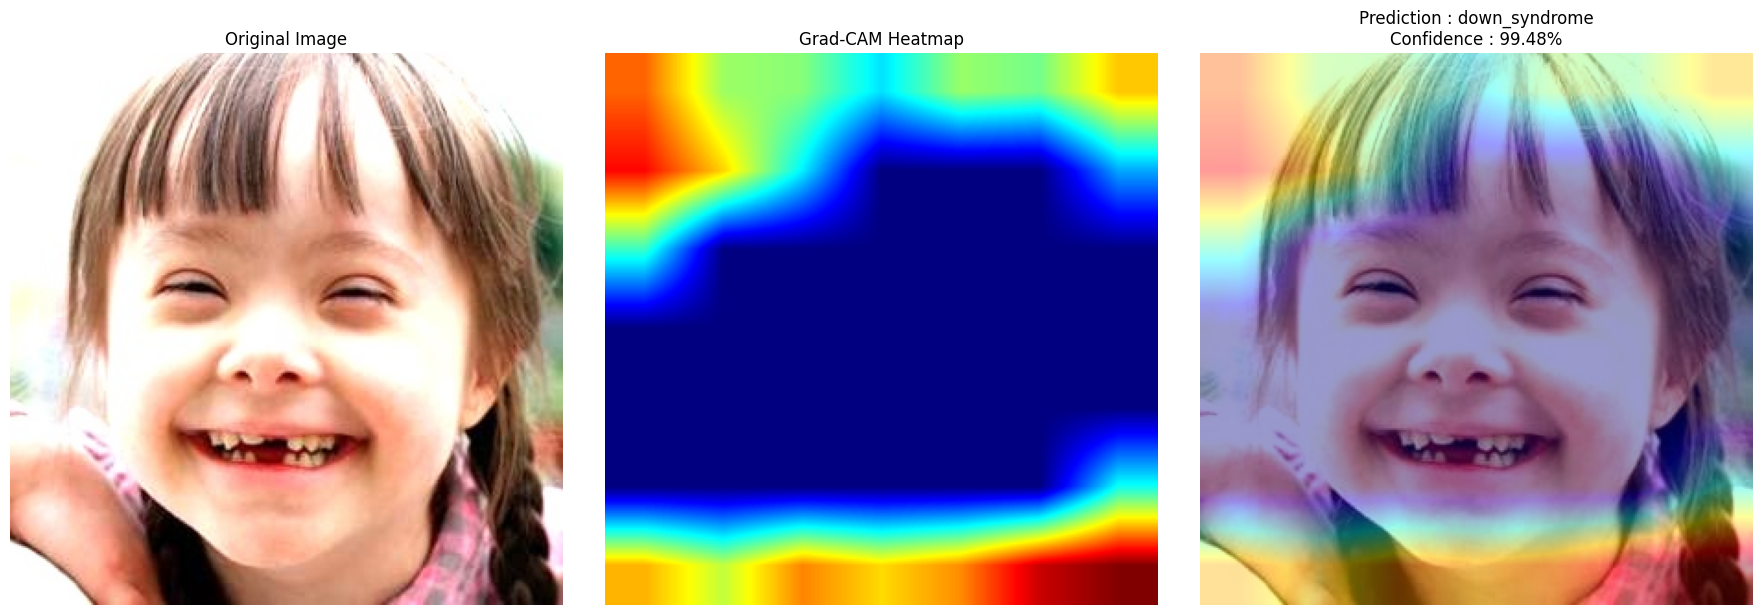


PART 4 COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# FINAL PREDICTION
# ============================================================

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

print("="*60)
print("Grad-CAM Visualization")
print("="*60)

# --------------------------------------------------
# LOAD TRAINED MODEL
# --------------------------------------------------

model = tf.keras.models.load_model("best_resnet50_model.keras")

print("Model Loaded Successfully!")

# --------------------------------------------------
# CLASS NAMES
# --------------------------------------------------

class_names = ["down_syndrome","healthy"]

# --------------------------------------------------
# UPLOAD IMAGE
# --------------------------------------------------

print("\nUpload an image")

uploaded = files.upload()

img_path = list(uploaded.keys())[0]

print("Image:",img_path)

# --------------------------------------------------
# LOAD IMAGE
# --------------------------------------------------

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_batch = np.expand_dims(img_array,axis=0)

img_batch = preprocess_input(img_batch)

# --------------------------------------------------
# PREDICTION
# --------------------------------------------------

prediction = model.predict(img_batch)[0][0]

healthy_probability = float(prediction)

down_probability = float(1-prediction)

if prediction>=0.5:

    predicted_class="healthy"

    confidence=healthy_probability

else:

    predicted_class="down_syndrome"

    confidence=down_probability

print("\n==========================")

print("Prediction")

print("==========================")

print("Predicted Class :",predicted_class)

print("Confidence :",round(confidence*100,2),"%")

print("Healthy Probability :",round(healthy_probability*100,2),"%")

print("Down Syndrome Probability :",round(down_probability*100,2),"%")

# --------------------------------------------------
# FIND LAST CONVOLUTION LAYER
# --------------------------------------------------

last_conv_layer = None

for layer in reversed(model.layers):

    if isinstance(layer,tf.keras.layers.Conv2D):

        last_conv_layer = layer.name

        break

print("\nLast Convolution Layer :",last_conv_layer)

# --------------------------------------------------
# CREATE GRAD MODEL
# --------------------------------------------------

grad_model = tf.keras.models.Model(

    [model.inputs],

    [

        model.get_layer(last_conv_layer).output,

        model.output

    ]

)

# --------------------------------------------------
# COMPUTE GRADIENTS
# --------------------------------------------------

with tf.GradientTape() as tape:

    conv_outputs,predictions = grad_model(img_batch)

    loss = predictions[:,0]

grads = tape.gradient(loss,conv_outputs)

pooled_grads = tf.reduce_mean(grads,axis=(0,1,2))

conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[...,tf.newaxis]

heatmap = tf.squeeze(heatmap)

heatmap = tf.maximum(heatmap,0)

heatmap = heatmap/tf.reduce_max(heatmap)

heatmap = heatmap.numpy()

# --------------------------------------------------
# RESIZE HEATMAP
# --------------------------------------------------

original = cv2.imread(img_path)

original = cv2.cvtColor(original,cv2.COLOR_BGR2RGB)

heatmap = cv2.resize(

    heatmap,

    (original.shape[1],original.shape[0])

)

heatmap = np.uint8(255*heatmap)

heatmap = cv2.applyColorMap(

    heatmap,

    cv2.COLORMAP_JET

)

heatmap = cv2.cvtColor(

    heatmap,

    cv2.COLOR_BGR2RGB

)

overlay = cv2.addWeighted(

    original,

    0.6,

    heatmap,

    0.4,

    0

)

# --------------------------------------------------
# DISPLAY RESULTS
# --------------------------------------------------

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)

plt.imshow(original)

plt.title("Original Image")

plt.axis("off")

plt.subplot(1,3,2)

plt.imshow(heatmap)

plt.title("Grad-CAM Heatmap")

plt.axis("off")

plt.subplot(1,3,3)

plt.imshow(overlay)

plt.title(f"Prediction : {predicted_class}\nConfidence : {confidence*100:.2f}%")

plt.axis("off")

plt.tight_layout()

plt.show()

print("\nPART 4 COMPLETED SUCCESSFULLY")

Grad-CAM Visualization
Model Loaded Successfully!

Upload an image


Saving healty_1_brightness.jpg to healty_1_brightness.jpg
Image: healty_1_brightness.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step

Prediction
Predicted Class : healthy
Confidence : 73.93 %
Healthy Probability : 73.93 %
Down Syndrome Probability : 26.07 %

Last Convolution Layer : conv5_block3_3_conv


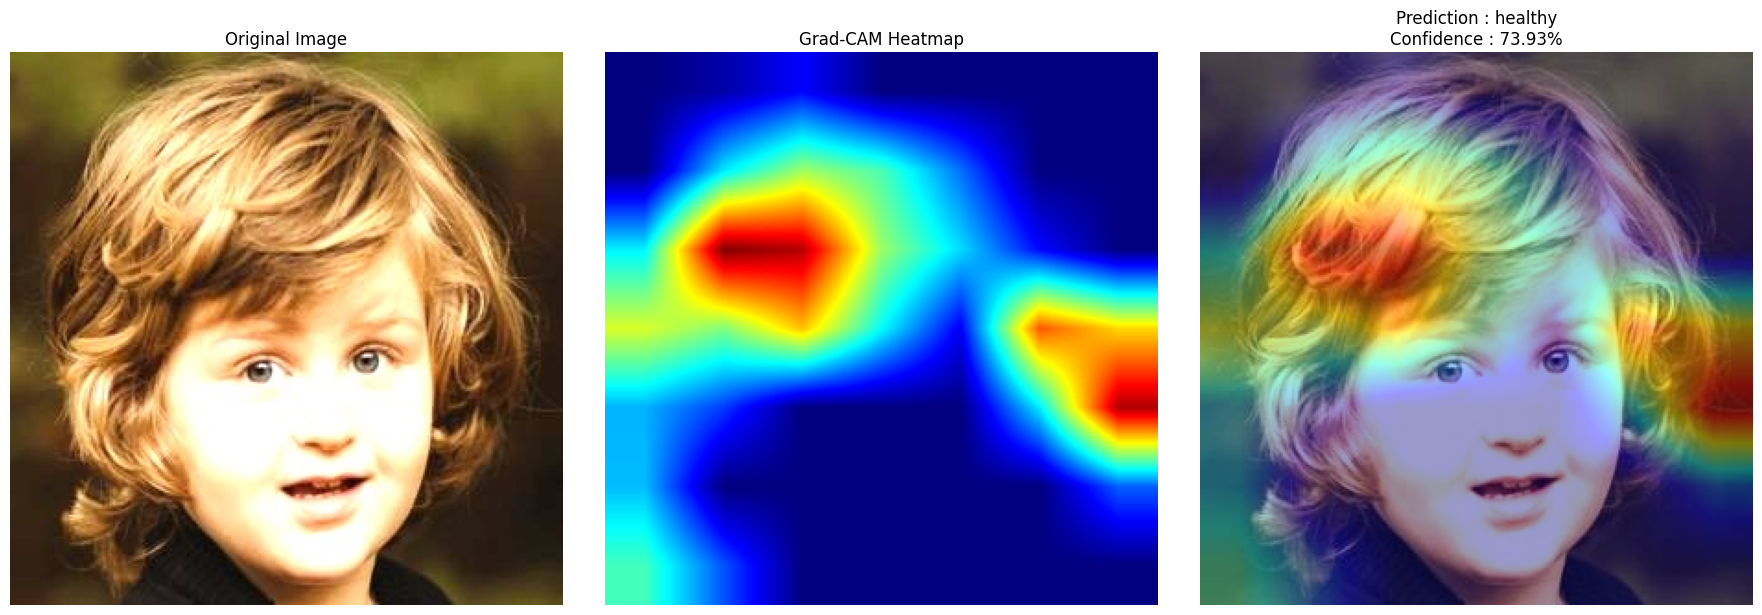


PART 4 COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# FINAL PREDICTION
# ============================================================

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

print("="*60)
print("Grad-CAM Visualization")
print("="*60)

# --------------------------------------------------
# LOAD TRAINED MODEL
# --------------------------------------------------

model = tf.keras.models.load_model("best_resnet50_model.keras")

print("Model Loaded Successfully!")

# --------------------------------------------------
# CLASS NAMES
# --------------------------------------------------

class_names = ["down_syndrome","healthy"]

# --------------------------------------------------
# UPLOAD IMAGE
# --------------------------------------------------

print("\nUpload an image")

uploaded = files.upload()

img_path = list(uploaded.keys())[0]

print("Image:",img_path)

# --------------------------------------------------
# LOAD IMAGE
# --------------------------------------------------

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_batch = np.expand_dims(img_array,axis=0)

img_batch = preprocess_input(img_batch)

# --------------------------------------------------
# PREDICTION
# --------------------------------------------------

prediction = model.predict(img_batch)[0][0]

healthy_probability = float(prediction)

down_probability = float(1-prediction)

if prediction>=0.5:

    predicted_class="healthy"

    confidence=healthy_probability

else:

    predicted_class="down_syndrome"

    confidence=down_probability

print("\n==========================")

print("Prediction")

print("==========================")

print("Predicted Class :",predicted_class)

print("Confidence :",round(confidence*100,2),"%")

print("Healthy Probability :",round(healthy_probability*100,2),"%")

print("Down Syndrome Probability :",round(down_probability*100,2),"%")

# --------------------------------------------------
# FIND LAST CONVOLUTION LAYER
# --------------------------------------------------

last_conv_layer = None

for layer in reversed(model.layers):

    if isinstance(layer,tf.keras.layers.Conv2D):

        last_conv_layer = layer.name

        break

print("\nLast Convolution Layer :",last_conv_layer)

# --------------------------------------------------
# CREATE GRAD MODEL
# --------------------------------------------------

grad_model = tf.keras.models.Model(

    [model.inputs],

    [

        model.get_layer(last_conv_layer).output,

        model.output

    ]

)

# --------------------------------------------------
# COMPUTE GRADIENTS
# --------------------------------------------------

with tf.GradientTape() as tape:

    conv_outputs,predictions = grad_model(img_batch)

    loss = predictions[:,0]

grads = tape.gradient(loss,conv_outputs)

pooled_grads = tf.reduce_mean(grads,axis=(0,1,2))

conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[...,tf.newaxis]

heatmap = tf.squeeze(heatmap)

heatmap = tf.maximum(heatmap,0)

heatmap = heatmap/tf.reduce_max(heatmap)

heatmap = heatmap.numpy()

# --------------------------------------------------
# RESIZE HEATMAP
# --------------------------------------------------

original = cv2.imread(img_path)

original = cv2.cvtColor(original,cv2.COLOR_BGR2RGB)

heatmap = cv2.resize(

    heatmap,

    (original.shape[1],original.shape[0])

)

heatmap = np.uint8(255*heatmap)

heatmap = cv2.applyColorMap(

    heatmap,

    cv2.COLORMAP_JET

)

heatmap = cv2.cvtColor(

    heatmap,

    cv2.COLOR_BGR2RGB

)

overlay = cv2.addWeighted(

    original,

    0.6,

    heatmap,

    0.4,

    0

)

# --------------------------------------------------
# DISPLAY RESULTS
# --------------------------------------------------

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)

plt.imshow(original)

plt.title("Original Image")

plt.axis("off")

plt.subplot(1,3,2)

plt.imshow(heatmap)

plt.title("Grad-CAM Heatmap")

plt.axis("off")

plt.subplot(1,3,3)

plt.imshow(overlay)

plt.title(f"Prediction : {predicted_class}\nConfidence : {confidence*100:.2f}%")

plt.axis("off")

plt.tight_layout()

plt.show()

